# Support Vector Machines: Linear vs Non-Linear Kernels
### A hands-on practice notebook using the `iris` dataset (built into Seaborn)

**Goals for this session**
1. Understand the maximum-margin idea behind SVMs and what "support vectors" are.
2. Train a **linear-kernel SVM** and a **non-linear (RBF-kernel) SVM** on the same data.
3. Visualize decision boundaries for both, side by side.
4. Compare their performance quantitatively (accuracy, confusion matrix, support-vector count).
5. See, hands-on, how the `C` and `gamma` hyperparameters reshape the decision boundary.
6. Walk away with reusable plotting recipes for any 2D SVM problem.

> **Why the iris dataset?** It is small, clean, and has one class (*setosa*) that is linearly
> separable from the other two, while *versicolor* and *virginica* overlap in a way that a
> straight line cannot cleanly separate. That makes it the textbook dataset for showing
> **why** we sometimes need a non-linear kernel — you can literally see the difference.


## 1. Imports and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Consistent, presentable plots
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load and explore the data

We load the classic `iris` dataset directly from Seaborn's built-in dataset repository —
no external download needed.

In [2]:
iris = sns.load_dataset("iris")
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print(iris.shape)
print(iris['species'].value_counts())
iris.describe()


(150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Hint (visualization):** `sns.pairplot` with `hue="species"` is the fastest way to
spot which pair of features gives the cleanest — or messiest — class separation before
you even train a model. Look for the pair where *versicolor* and *virginica* overlap the most;
that is exactly where a linear boundary will struggle and a non-linear one will help.

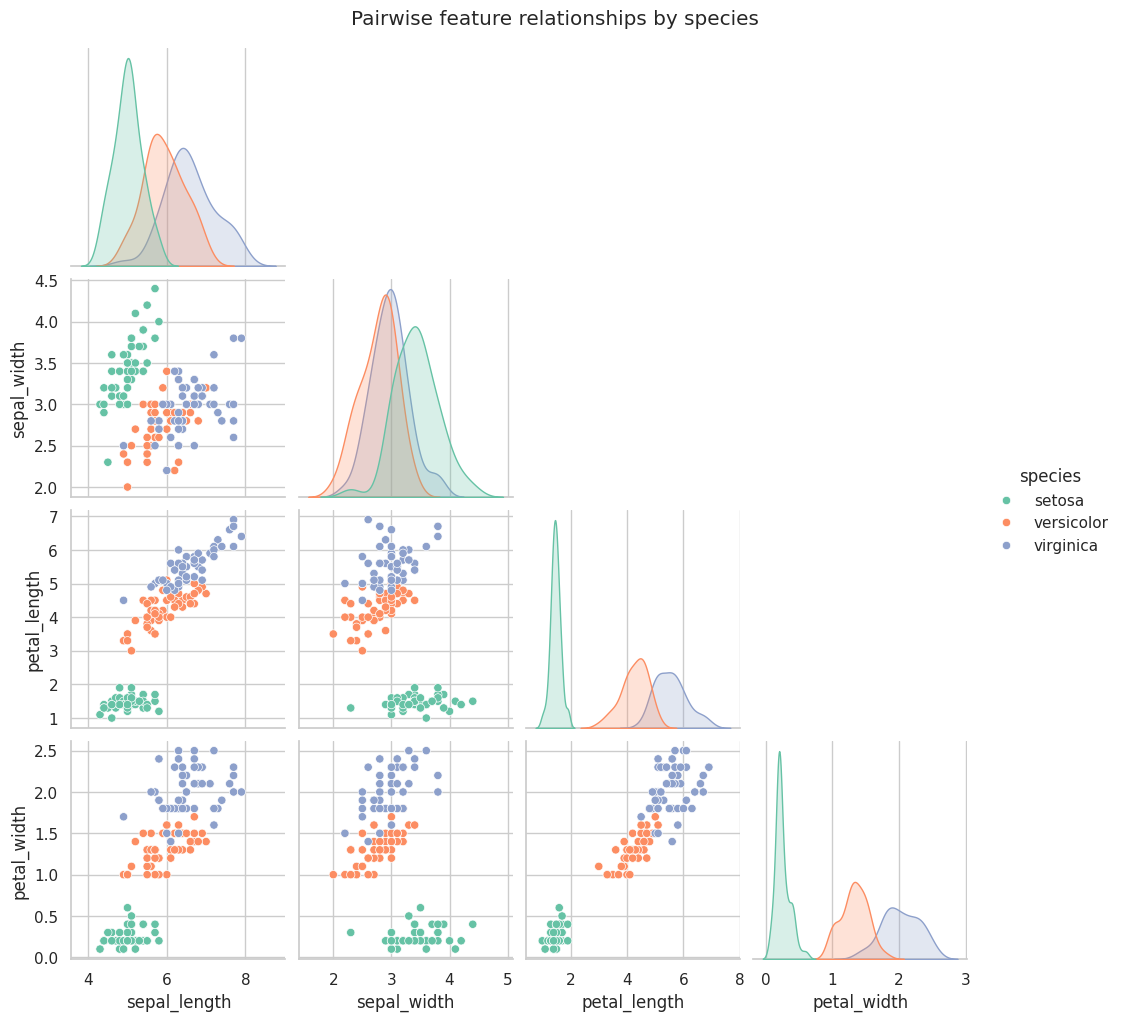

In [4]:
sns.pairplot(iris, hue="species", corner=True, palette="Set2")
plt.suptitle("Pairwise feature relationships by species", y=1.02)
plt.show()


## 3. Prepare a 2D version of the problem (for visualization)

SVM decision boundaries are easiest to *see* in 2D. We will deliberately use only two
features — **petal_length** and **petal_width** — because the pairplot above shows they
separate the three species better than the sepal measurements do, while still leaving a
non-trivial overlap between *versicolor* and *virginica*.

> Later, feel free to repeat the whole notebook with all 4 features (drop the 2D plots,
> keep the metrics) to see if accuracy improves.

In [5]:
FEATURES = ["petal_length", "petal_width"]
TARGET = "species"

X = iris[FEATURES].values
le = LabelEncoder()
y = le.fit_transform(iris[TARGET])   # setosa=0, versicolor=1, virginica=2
class_names = le.classes_
print(dict(zip(class_names, range(len(class_names)))))


{'setosa': 0, 'versicolor': 1, 'virginica': 2}


**Hint:** SVMs are distance-based (they rely on margins), so features on different
scales will silently distort the boundary. Always `StandardScaler` (or similar) your
features before fitting an SVM — this is easy to forget and is a very common source of
"why is my SVM performing badly" bugs.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape:", X_train_s.shape, " Test shape:", X_test_s.shape)


Train shape: (112, 2)  Test shape: (38, 2)


## 4. A reusable decision-boundary plotting helper

This is the single most useful plotting recipe for any 2-feature classifier. The idea:

1. Build a fine mesh grid covering the feature space.
2. Ask the trained model to predict a class for *every point* on that grid.
3. Draw the predictions as filled contours (`contourf`) — the boundaries between colors
   *are* the model's decision boundary.
4. Overlay the actual training points, and circle the support vectors.

Keep this function around — you will reuse it for almost every 2D classifier you train
this term (Logistic Regression, Decision Trees, KNN, etc.), not just SVMs.

In [7]:
def plot_decision_boundary(model, X, y, ax=None, title="", class_names=None,
                            show_support_vectors=True, h=0.02):
    """Plot a trained classifier's decision regions for a 2D feature space.

    Parameters
    ----------
    model : fitted classifier with .predict()
    X, y  : 2D feature array and integer labels used to fit the model (scaled space)
    ax    : matplotlib axis (creates one if None)
    h     : mesh step size (smaller = smoother boundary, slower plot)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="Set2")
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="Set2",
                          edgecolor="k", s=40, zorder=3)

    if show_support_vectors and hasattr(model, "support_vectors_"):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=140, facecolors="none", edgecolors="black",
                   linewidths=1.4, zorder=4, label="Support vectors")
        ax.legend(loc="best")

    ax.set_xlabel("petal_length (scaled)")
    ax.set_ylabel("petal_width (scaled)")
    ax.set_title(title)
    return ax


## 5. Train the Linear-kernel SVM

`kernel="linear"` fits a straight decision boundary (a straight *hyperplane* in higher
dimensions). It works well when classes are roughly linearly separable.

In [8]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)
svm_linear.fit(X_train_s, y_train)

y_pred_linear = svm_linear.predict(X_test_s)
acc_linear = accuracy_score(y_test, y_pred_linear)

print(f"Linear SVM test accuracy: {acc_linear:.3f}")
print(f"Number of support vectors per class: {svm_linear.n_support_}")
print()
print(classification_report(y_test, y_pred_linear, target_names=class_names))


Linear SVM test accuracy: 0.921
Number of support vectors per class: [ 2 11  9]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



## 6. Train the Non-Linear (RBF-kernel) SVM

`kernel="rbf"` (Radial Basis Function) can bend the decision boundary around clusters
of points — it implicitly maps the data into a much higher-dimensional space where a
straight-line separator *would* work, then maps that boundary back. Two key
hyperparameters:

- **`C`** — how much the model is penalized for misclassifying training points
  (low C = wider margin, more tolerance for errors; high C = tries hard to classify
  every training point correctly, risking overfitting).
- **`gamma`** — how far the influence of a single training point reaches
  (low gamma = far-reaching, smoother boundary; high gamma = very local, wigglier
  boundary, risking overfitting).

In [9]:
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_rbf.fit(X_train_s, y_train)

y_pred_rbf = svm_rbf.predict(X_test_s)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"RBF SVM test accuracy: {acc_rbf:.3f}")
print(f"Number of support vectors per class: {svm_rbf.n_support_}")
print()
print(classification_report(y_test, y_pred_rbf, target_names=class_names))


RBF SVM test accuracy: 0.921
Number of support vectors per class: [ 5 12 12]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



## 7. Side-by-side decision boundary comparison

This is the visual payoff: the same data, the same train/test split, only the kernel
changes. Watch what happens at the *versicolor/virginica* border in particular.

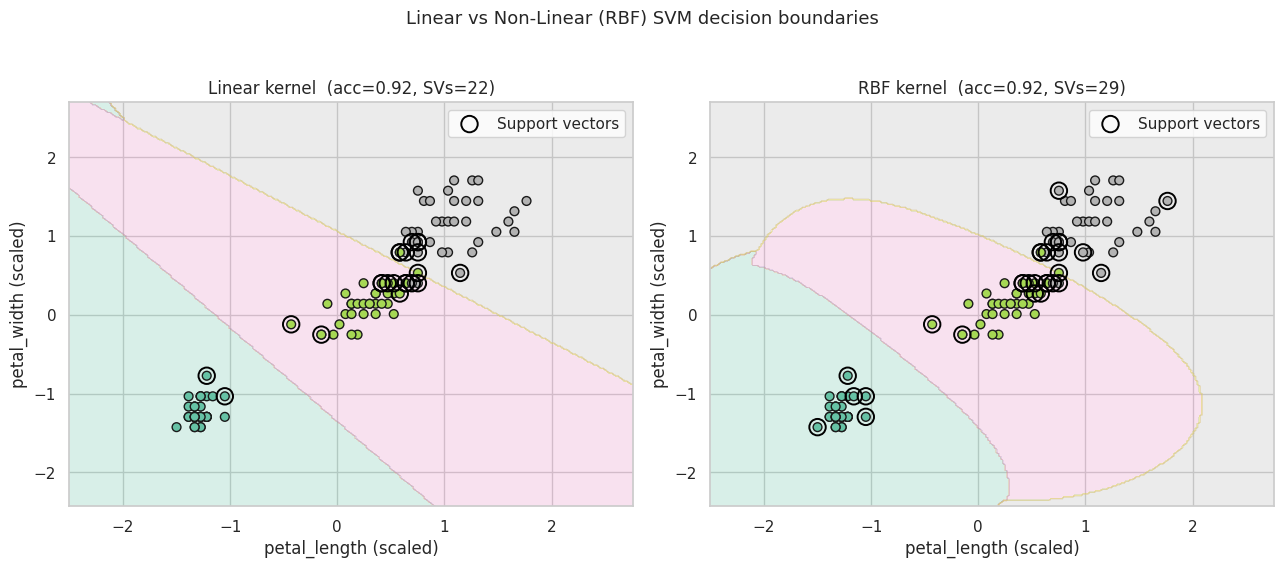

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

plot_decision_boundary(svm_linear, X_train_s, y_train, ax=axes[0],
                        title=f"Linear kernel  (acc={acc_linear:.2f}, "
                              f"SVs={svm_linear.support_vectors_.shape[0]})")
plot_decision_boundary(svm_rbf, X_train_s, y_train, ax=axes[1],
                        title=f"RBF kernel  (acc={acc_rbf:.2f}, "
                              f"SVs={svm_rbf.support_vectors_.shape[0]})")

plt.suptitle("Linear vs Non-Linear (RBF) SVM decision boundaries", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


**What to look for:**
- The **linear** boundary is made of straight line segments — it cannot curve around a
  cluster, so points of one class sitting "inside" the region of another are
  unavoidably misclassified.
- The **RBF** boundary bends around clusters, generally fitting the *versicolor*/
  *virginica* overlap more snugly — often (not always) at the cost of a less
  "interpretable" boundary and more support vectors.

## 8. Confusion matrices side by side

Accuracy alone hides *which* classes get confused. Since *setosa* is linearly separable
from the rest, both models should get it perfectly right — the interesting errors will
be between *versicolor* and *virginica*.

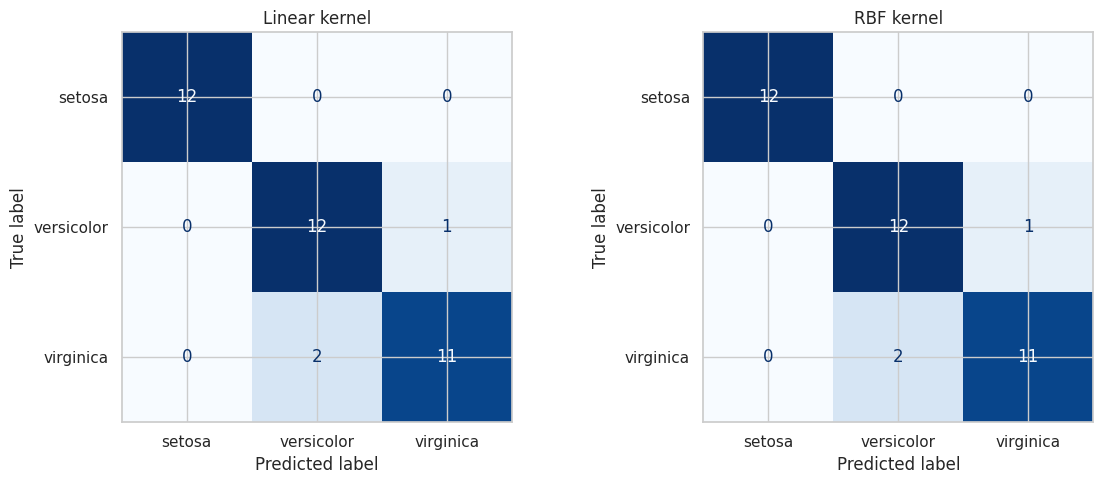

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_linear, display_labels=class_names, ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Linear kernel")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rbf, display_labels=class_names, ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("RBF kernel")

plt.tight_layout()
plt.show()


## 9. Quantitative comparison table

Beyond accuracy: number of support vectors is itself informative. A model that needs
*more* support vectors relative to the training set size is leaning harder on
individual data points and may generalize less predictably.

In [12]:
comparison = pd.DataFrame({
    "Kernel": ["Linear", "RBF"],
    "Test Accuracy": [acc_linear, acc_rbf],
    "Support Vectors (total)": [svm_linear.support_vectors_.shape[0],
                                 svm_rbf.support_vectors_.shape[0]],
    "Support Vectors (% of train set)": [
        100 * svm_linear.support_vectors_.shape[0] / len(X_train_s),
        100 * svm_rbf.support_vectors_.shape[0] / len(X_train_s),
    ],
})
comparison.round(3)


,Kernel,Test Accuracy,Support Vectors (total),Support Vectors (% of train set)
0,Linear,0.921,22,19.643
1,RBF,0.921,29,25.893


## 10. Hyperparameter intuition: effect of `C` (linear) and `gamma` (RBF)

**Hint (visualization):** a grid of small subplots, one value per panel, is the clearest
way to show a hyperparameter's effect — the eye can compare boundary shape across panels
instantly, which a single overlaid plot cannot do cleanly.

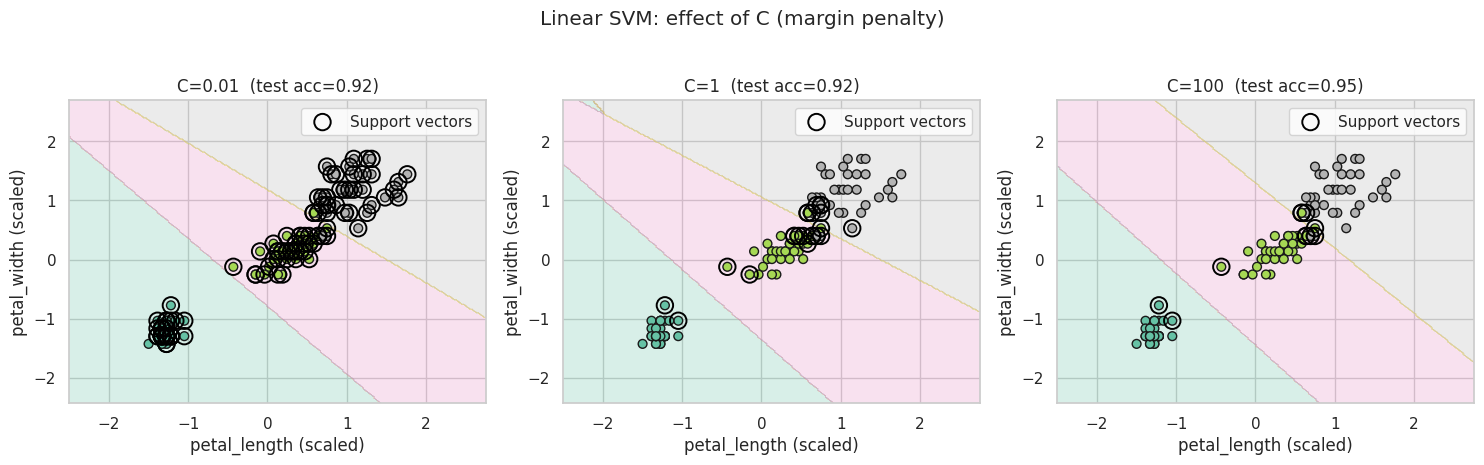

In [13]:
C_values = [0.01, 1, 100]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, C_values):
    model = SVC(kernel="linear", C=c, random_state=RANDOM_STATE).fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    plot_decision_boundary(model, X_train_s, y_train, ax=ax,
                            title=f"C={c}  (test acc={acc:.2f})")
plt.suptitle("Linear SVM: effect of C (margin penalty)", y=1.03)
plt.tight_layout()
plt.show()


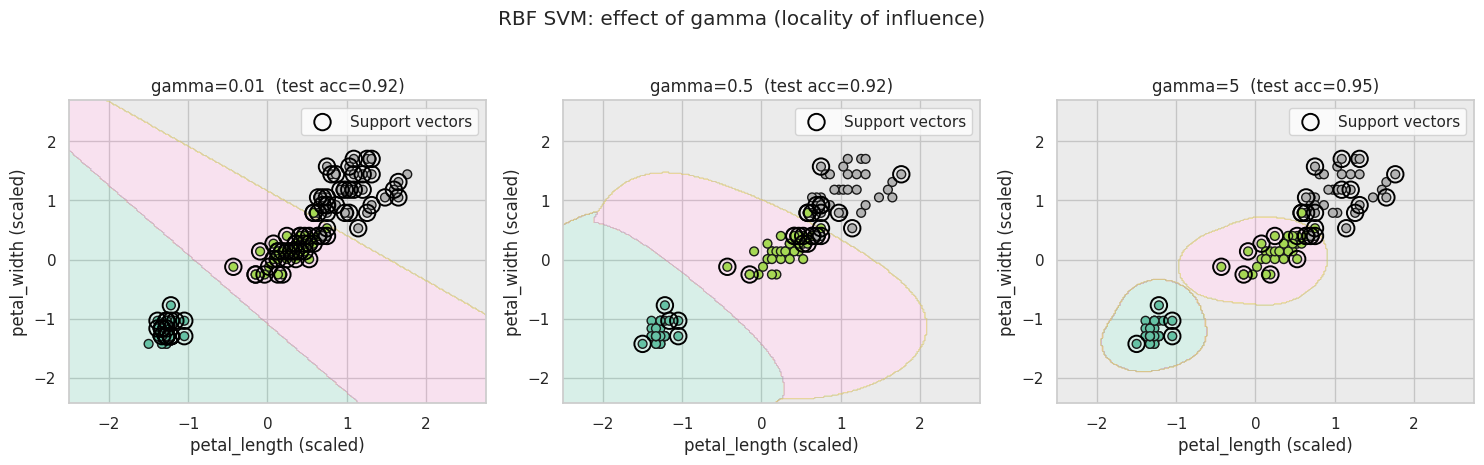

In [14]:
gamma_values = [0.01, 0.5, 5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, g in zip(axes, gamma_values):
    model = SVC(kernel="rbf", C=1.0, gamma=g, random_state=RANDOM_STATE).fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    plot_decision_boundary(model, X_train_s, y_train, ax=ax,
                            title=f"gamma={g}  (test acc={acc:.2f})")
plt.suptitle("RBF SVM: effect of gamma (locality of influence)", y=1.03)
plt.tight_layout()
plt.show()


**What to look for:**
- Small `C` → wider margin, may misclassify some training points, usually smoother
  and more generalizable.
- Large `C` → boundary bends to fit training points as closely as possible; watch for
  a boundary that looks "suspicious" or overfit.
- Small `gamma` → each point's influence reaches far, boundary stays smooth/almost linear.
- Large `gamma` → influence is very local, boundary can develop small islands around
  individual points — a classic overfitting signature. If you see isolated colored
  "islands" around single points, gamma is too high.

## 11. Bonus: polynomial kernel for comparison

A third common kernel choice. Try degree 2 and 3 and see where it lands relative to
linear and RBF.

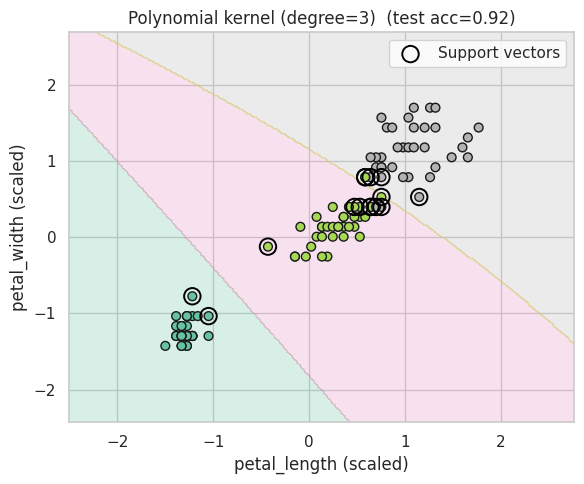

Polynomial SVM test accuracy: 0.921


In [15]:
svm_poly = SVC(kernel="poly", degree=3, C=1.0, coef0=1, random_state=RANDOM_STATE)
svm_poly.fit(X_train_s, y_train)
acc_poly = accuracy_score(y_test, svm_poly.predict(X_test_s))

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(svm_poly, X_train_s, y_train, ax=ax,
                        title=f"Polynomial kernel (degree=3)  (test acc={acc_poly:.2f})")
plt.tight_layout()
plt.show()

print(f"Polynomial SVM test accuracy: {acc_poly:.3f}")


## 12. Summary & discussion questions

**Recap table:**

| Kernel | Boundary shape | When to prefer it |
|---|---|---|
| Linear | Straight hyperplane | Classes are (roughly) linearly separable; you want an interpretable, fast model; many features relative to samples (e.g., text data) |
| RBF | Smooth curved regions | Classes overlap in a non-linear way; you have enough data to tune `C`/`gamma` safely |
| Polynomial | Curved, can have multiple bends | Rarely the first choice today; occasionally useful when you have domain reason to expect polynomial-shaped interactions |

**Try it yourself (extend this notebook):**
1. Repeat the whole workflow using **all four** iris features (drop the 2D decision-boundary
   plots, keep the metrics table) — does accuracy improve?
2. Use `GridSearchCV` to tune `C` and `gamma` for the RBF model instead of guessing values.
3. Swap in a different Seaborn dataset (`sns.load_dataset("penguins")`) and repeat —
   pick two numeric features with visible class overlap, handle missing values first.
4. Plot the **margin** explicitly for the linear SVM using `decision_function()` and
   `contour` at levels `[-1, 0, 1]` — this shows the margin boundaries, not just the
   decision boundary.

**General plotting/visualization hints to remember:**
- Always scale features before fitting *and* before plotting an SVM boundary — plot in
  the same (scaled) space the model was trained on.
- `contourf` for filled decision regions, `contour` with `levels=[-1,0,1]` for margin lines.
- Circle support vectors with `facecolors="none"` so the class color still shows through.
- Use a consistent categorical palette (e.g., `"Set2"`) across all panels in a comparison
  so the same class always has the same color.
- For 3+ features, don't skip visualization — reduce to 2D first with PCA
  (`sklearn.decomposition.PCA(n_components=2)`) purely for plotting, while still
  training/evaluating the real model on the full feature set.
